# Regresión lineal: implementación desde cero en Python

## 1. Configuración Google Drive

In [ ]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [ ]:
ruta = '/gdrive/MyDrive/Colab Notebooks/01_2021-07-FundamentosDL/1.4/dataset.csv'

## 2. Lectura y visualización del set de datos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(100)

In [ ]:
data = pd.read_csv(ruta)

In [ ]:
data.head()

,Area,Precio
0,152.272727,65928.86015
1,102.272727,44477.41849
2,222.727273,95848.62198
3,79.545455,44964.89827
4,86.363636,34367.39122


In [ ]:
data.shape

(100, 2)

In [ ]:
x1 = data['Area'].values
y = data['Precio'].values

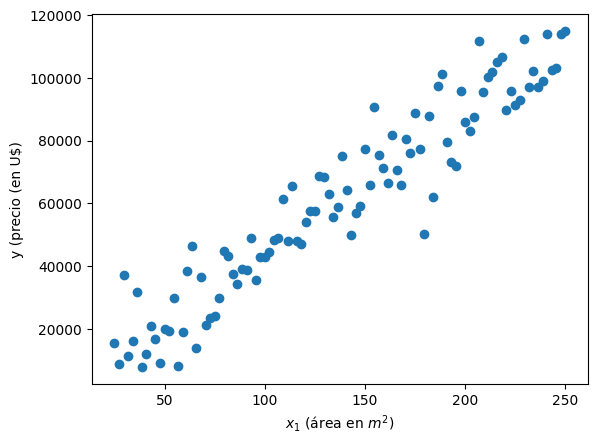

In [ ]:
plt.scatter(x1,y)
plt.xlabel('$x_1$ (área en $m^2)$')
plt.ylabel('y (precio (en U$)');

## 3. Funciones para construir el modelo lineal

###3.1 Pérdida

$L(\omega ,b)=\frac{1}{2m}\sum_{i=1}^m [w x_1^{(i)}+b-y^{(i)}]^2$

In [ ]:
def calcular_perdida(x,y,w,b,m):
	errores_individuales = np.square([w*x+b-y])
	perdida = np.sum(errores_individuales)/(2*m)

	return perdida

### 3.2 Gradiente descendente

Los parámetros (coeficientes) se actualizan así:

$\omega \leftarrow \omega - \alpha \frac{\partial L(\omega ,b)}{\partial \omega}$

$b \leftarrow b - \alpha \frac{\partial L(\omega ,b)}{\partial b}$

donde las derivadas parciales son:

$\frac{\partial L(\omega ,b)}{\partial \omega} = \frac{1}{m} \sum_{i=1}^m x_1^{(i)} [w \cdot x_1^{(i)} + b - y^{(i)}]$

$\frac{\partial L(\omega ,b)}{\partial b} = \frac{1}{m} \sum_{i=1}^m [w \cdot x_1^{(i)} + b - y^{(i)}]$

In [ ]:
def gradiente_descendente(w,b,alpha,x,y,m):
  # dL_w y dL_b
  dL_w = np.sum(x*(w*x+b-y))/m
  dL_b = np.sum(w*x+b-y)/m

  # Actualización de pesos
  w = w - alpha*dL_w
  b = b - alpha*dL_b

  return w,b

### 3.3 Predicción con el modelo ya entrenado

$\hat{y} = w \cdot x_1 + b$

In [ ]:
def predecir(x,w,b):
	y_pred = w*x + b

	return y_pred

## 4. Entrenamiento

In [ ]:
# Modificar estos hiper-parámetros para observar diferentes comportamientos

nits = 20				# Número de iteraciones
alpha = 0.00001 # Tasa de aprendizaje (0.00001)


In [ ]:
def entrenar(x,y,nits,alpha):
	m = x.shape[0] 	# Número de datos de entrenamiento

	# Inicializar pesos (acá np.random.seed(100) garantiza que siempre inicializo en los mismos valores)
	w = np.random.rand()
	b = np.random.rand()

	# Pérdida inicial
	perdida = []
	perdida_i = calcular_perdida(x,y,w,b,m)
	perdida.append(perdida_i)

	# Imprimir valores iniciales
	print('Inicialización. '  + 'Loss: '
			+ str(perdida_i) + ', w: ' + str(w) + ', b: ' + str(b))

	# Entrenamiento
	for it in range(nits):
		# Aplicar gradiente descendente
		w, b = gradiente_descendente(w,b,alpha,x,y,m)

		# Actualizar pérdida
		perdida_it = calcular_perdida(x,y,w,b,m)
		perdida.append(perdida_it)

		# Imprimir en pantalla
		print('Iteración: ' + str(it) + '. ' + 'Loss: '
			+ str(perdida_it) + ', w: ' + str(w) + ', b: ' + str(b))

	return w, b, perdida

In [ ]:
# Ejecutar entrenamiento
w, b, perdida = entrenar(x1,y,nits,alpha)

Inicialización. Loss: 2342513281.6845264, w: 0.5434049417909654, b: 0.27836938509379616
Iteración: 0. Loss: 1399076234.1410716, w: 103.8519481105296, b: 0.8917790839922826
Iteración: 1. Loss: 842774418.932353, w: 183.1815001792977, b: 1.3631334019367647
Iteración: 2. Loss: 514748600.5259574, w: 244.09783480626044, b: 1.725404872243511
Iteración: 3. Loss: 321326730.20723486, w: 290.8748515968026, b: 2.0039127597234803
Iteración: 4. Loss: 207274671.40872478, w: 326.7944335305008, b: 2.2180994640375795
Iteración: 5. Loss: 140023371.95087615, w: 354.3767043552464, b: 2.3828946013258006
Iteración: 6. Loss: 100368346.60418291, w: 375.5568408412684, b: 2.5097624682786237
Iteración: 7. Loss: 76985585.9717157, w: 391.8208450688884, b: 2.607506378884497
Iteración: 8. Loss: 63197837.979843065, w: 404.3098025537505, b: 2.6828863062382866
Iteración: 9. Loss: 55067831.500292644, w: 413.89994097497845, b: 2.7410931632511173
Iteración: 10. Loss: 50273937.25105092, w: 421.2641064384394, b: 2.7861129978

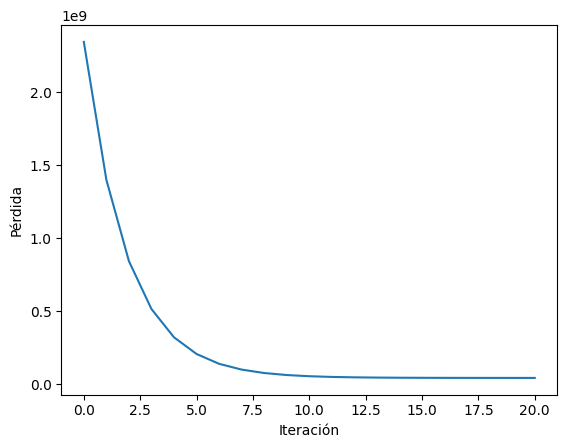

In [ ]:
# Dibujar comportamiento del error
plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.show()

Text(0, 0.5, 'y (precio (en U$)')

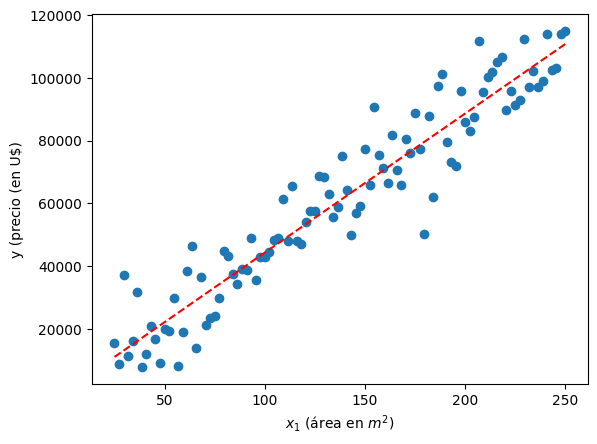

In [ ]:
# Dibujar recta resultante
x_pred = np.linspace(x1.min(),x1.max(),x1.shape[0])
y_pred = predecir(x_pred,w,b)

plt.scatter(x1,y)
plt.plot(x_pred,y_pred,'r--')
plt.xlabel('$x_1$ (área en $m^2$)')
plt.ylabel('y (precio (en U$)')